In [ ]:
# import tensorflow as tf

# # Check if TensorFlow can access a GPU
# if tf.config.list_physical_devices('GPU'):
#     print("GPU is available.")
# else:
#     print("GPU is not available.")


selecting png and converting them to npy

In [ ]:
# import os
# import numpy as np
# from PIL import Image

# def save_pngs_to_npy(input_folder):
#     image_arrays = [
#         np.array(Image.open(os.path.join(input_folder, f)).convert('RGB'))
#         for f in os.listdir(input_folder) if f.lower().endswith(".png")
#     ]

#     if not image_arrays:
#         raise ValueError("No PNG files found in the specified folder.")

#     np.save(os.path.join(input_folder, "11000_noise_rotation_aug.npy"), np.stack(image_arrays, axis=0))

# # Use your specified path
# input_folder = "/home/user/Desktop/Anindita_digitization/noise and rotation/New folder/11000_noise_rotation_aug"

# save_pngs_to_npy(input_folder)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import tqdm
import tensorflow as tf
from tensorflow.keras.models import Model

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Cropping2D,UpSampling2D
from tensorflow.keras.layers import Conv2DTranspose, ZeroPadding2D

2025-11-05 09:37:10.321589: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-05 09:37:10.334742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762315630.350361   16088 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762315630.355143   16088 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762315630.366648   16088 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
noisy_images = np.load("/home/user/Desktop/Anindita_digitization/noise and rotation/New folder/11000_noise_rotation_aug.npy")

In [3]:
noisy_images.shape

(995, 425, 550, 3)

In [4]:
ground_truth_images = np.load("/home/user/Desktop/Anindita_digitization/noise and rotation/New folder/11000_50DPI.npy")

In [5]:
ground_truth_images.shape

(995, 425, 550, 3)

processing the images

In [6]:
processed_images = []
for image in noisy_images:
    # Step 1: Convert RGB to HSV and extract the value channel
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    value_channel = hsv_image[:, :, 2]
    # Append processed image to the list
    processed_images.append(value_channel)

# Convert the list of processed images to a numpy array
processed_ip_images = np.array(processed_images)

In [7]:
processed_ip_images.shape

(995, 425, 550)

In [8]:
processed_images = []
for image in ground_truth_images:
    # Step 1: Convert RGB to HSV and extract the value channel
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    value_channel = hsv_image[:, :, 2]
    # Append processed image to the list
    processed_images.append(value_channel)

# Convert the list of processed images to a numpy array
processed_gt_images = np.array(processed_images)

In [9]:
processed_gt_images.shape

(995, 425, 550)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Basic GAN Generator
class GANGenerator(layers.Layer):
    def __init__(self, embed_dim=96):
        super().__init__()
        self.fc1 = layers.Dense(embed_dim * 4 * 4)  # Fully connected layer to match desired output size
        self.reshape = layers.Reshape((4, 4, embed_dim))  # Reshape to 4x4xembed_dim
        self.upconv1 = layers.Conv2DTranspose(embed_dim // 2, (3, 3), strides=2, padding='same')
        self.upconv2 = layers.Conv2DTranspose(embed_dim // 4, (3, 3), strides=2, padding='same')
        self.upconv3 = layers.Conv2DTranspose(embed_dim // 8, (3, 3), strides=2, padding='same')
        self.upconv4 = layers.Conv2DTranspose(embed_dim // 16, (3, 3), strides=2, padding='same')
        self.output_layer = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')

    def call(self, x):
        # Flatten the input tensor (c5) before passing through fully connected layers
        x = layers.Reshape((-1,))(x)  # Flatten the tensor
        x = self.fc1(x)  # Apply the fully connected layer
        x = self.reshape(x)  # Reshape it back to (4, 4, embed_dim)
        x = self.upconv1(x)
        x = self.upconv2(x)
        x = self.upconv3(x)
        x = self.upconv4(x)
        x = self.output_layer(x)  # Final output layer
        return x

# UNet with GAN Generator instead of Swin Transformer
def unet_with_gan(input_shape=(425, 550, 1), embed_dim=96, depth=1):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    # GAN Generator Block (instead of Swin Transformer)
    gan_generator = GANGenerator(embed_dim=embed_dim)
    gan_out = gan_generator(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(gan_out)

    # Instead of using dynamic padding, we will calculate the static target shape of c4
    c4_shape = c4.shape[1:3]  # Static shape for c4 (height, width)

    # Use resize_with_crop_or_pad to ensure matching dimensions
    u6 = layers.Lambda(lambda x: tf.image.resize_with_crop_or_pad(x, target_height=c4_shape[0], target_width=c4_shape[1]))(u6)

    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)

    c3_shape = c3.shape[1:3]  # Static shape for c3
    u7 = layers.Lambda(lambda x: tf.image.resize_with_crop_or_pad(x, target_height=c3_shape[0], target_width=c3_shape[1]))(u7)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)

    c2_shape = c2.shape[1:3]  # Static shape for c2
    u8 = layers.Lambda(lambda x: tf.image.resize_with_crop_or_pad(x, target_height=c2_shape[0], target_width=c2_shape[1]))(u8)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)

    c1_shape = c1.shape[1:3]  # Static shape for c1
    u9 = layers.Lambda(lambda x: tf.image.resize_with_crop_or_pad(x, target_height=c1_shape[0], target_width=c1_shape[1]))(u9)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Test instantiation and summary
input_shape = (425, 550, 1)
model = unet_with_gan(input_shape)
model.summary()


W0000 00:00:1762315633.947673   16088 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 425, 550,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 425, 550,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 425, 550,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 212, 275,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 212, 275,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 212, 275,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 106, 137,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 106, 137,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 106, 137,  │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 53, 68,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 53, 68,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 53, 68,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 26, 34,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 26, 34,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 26, 34,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gan_generator       │ (None, 64, 64, 1) │ 347,659,7… │ conv2d_9[0][0]    │
│ (GANGenerator)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 128, 128,  │        640 │ gan_generator[0]

 Total params: 349,469,962 (1.30 GB)

 Trainable params: 349,469,962 (1.30 GB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.model_selection import train_test_split
train_noisy, val_noisy, train_clean, val_clean = train_test_split(processed_ip_images,processed_gt_images, test_size=0.1, random_state=42)

In [13]:
train_noisy.shape, val_noisy.shape, train_clean.shape, val_clean.shape

((895, 425, 550), (100, 425, 550), (895, 425, 550), (100, 425, 550))

In [14]:
import tensorflow as tf
import keras.backend as K
from tensorflow.keras import backend as K



# Normalize images to [0, 1] range
train_noisy = train_noisy / 255.0
train_clean = train_clean / 255.0
val_noisy = val_noisy / 255.0
val_clean = val_clean / 255.0

# Ensure images have a channel dimension
train_noisy = train_noisy[..., tf.newaxis]
train_clean = train_clean[..., tf.newaxis]
val_noisy = val_noisy[..., tf.newaxis]
val_clean = val_clean[..., tf.newaxis]



# --- Dice Loss ---
def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true_f = tf.reshape(y_true, [-1])  # Flatten the tensor using tf.reshape
    y_pred_f = tf.reshape(y_pred, [-1])  # Flatten the tensor using tf.reshape
    intersection = tf.reduce_sum(y_true_f * y_pred_f)  # Change K.sum to tf.reduce_sum
    dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)  # Change K.sum to tf.reduce_sum
    return 1 - dice

# --- Focal Loss ---
def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
    cross_entropy = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    weight = alpha * y_true * tf.pow(1 - y_pred, gamma) + (1 - alpha) * (1 - y_true) * tf.pow(y_pred, gamma)
    loss = weight * cross_entropy
    return tf.reduce_mean(loss)

# --- MS-SSIM Loss ---
def ms_ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim_multiscale(y_true, y_pred, max_val=1.0))



def custom_loss_dynamic(y_true, y_pred):
    ms_ssim = 1 - ms_ssim_loss(y_true, y_pred)  # actual MS-SSIM value
    dice = 1 - dice_loss(y_true, y_pred)        # actual Dice value
    focal = 1 - focal_loss(y_true, y_pred)      # actual Focal value

    # Get the current magnitude of each loss term
    ms_ssim_loss_val = tf.reduce_mean(ms_ssim)  # Use tf.reduce_mean instead of K.mean
    dice_loss_val = tf.reduce_mean(dice)        # Use tf.reduce_mean instead of K.mean
    focal_loss_val = tf.reduce_mean(focal)      # Use tf.reduce_mean instead of K.mean

    # Calculate total loss
    total_loss = ms_ssim_loss_val + dice_loss_val + focal_loss_val

    # Calculate dynamic weights based on loss magnitudes (inverse of the loss value)
    alpha = ms_ssim_loss_val / total_loss
    beta = dice_loss_val / total_loss
    gamma = focal_loss_val / total_loss

    # Combine the losses with dynamic weights
    return (
        alpha * (1 - ms_ssim) +
        beta * (1 - dice) +
        gamma * (1 - focal)
    )


In [15]:
# --- SSIM Metric for Evaluation ---
def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))



model.compile(
    optimizer='adam',
    loss=custom_loss_dynamic,
    metrics=[ssim_metric, 'accuracy']
)



In [16]:


# Train the model
history = model.fit(
    train_noisy, train_clean,
    validation_data=(val_noisy, val_clean),
    batch_size=8,
    epochs=100,
    verbose=1
)


Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 587s 5s/step - accuracy: 0.7952 - loss: 0.1324 - ssim_metric: 0.7908 - val_accuracy: 0.9642 - val_loss: 0.0638 - val_ssim_metric: 0.8668
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 511s 5s/step - accuracy: 0.9647 - loss: 0.0569 - ssim_metric: 0.8719 - val_accuracy: 0.9641 - val_loss: 0.0488 - val_ssim_metric: 0.8832
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 565s 5s/step - accuracy: 0.9641 - loss: 0.0478 - ssim_metric: 0.8838 - val_accuracy: 0.9641 - val_loss: 0.0446 - val_ssim_metric: 0.8890
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 566s 5s/step - accuracy: 0.9646 - loss: 0.0432 - ssim_metric: 0.8903 - val_accuracy: 0.9641 - val_loss: 0.0423 - val_ssim_metric: 0.8892
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 561s 5s/step - accuracy: 0.9642 - loss: 0.0420 - ssim_metric: 0.8909 - val_accuracy: 0.9641 - val_loss: 0.0407 - val_ssim_metric: 0.8925
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 512s 5s/step - accuracy: 0.9647 - loss: 0.0390 - ssim_metric: 0.8945 

2025-11-05 15:06:23.882881: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 14960000 bytes after encountering the first element of size 14960000 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


112/112 ━━━━━━━━━━━━━━━━━━━━ 502s 4s/step - accuracy: 0.9643 - loss: 0.0133 - ssim_metric: 0.9439 - val_accuracy: 0.9641 - val_loss: 0.0219 - val_ssim_metric: 0.9275
Epoch 39/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9645 - loss: 0.0131 - ssim_metric: 0.9450

2025-11-05 15:15:45.538794: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 14960000 bytes after encountering the first element of size 14960000 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


112/112 ━━━━━━━━━━━━━━━━━━━━ 562s 4s/step - accuracy: 0.9645 - loss: 0.0131 - ssim_metric: 0.9450 - val_accuracy: 0.9641 - val_loss: 0.0218 - val_ssim_metric: 0.9272
Epoch 40/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 502s 4s/step - accuracy: 0.9645 - loss: 0.0127 - ssim_metric: 0.9461 - val_accuracy: 0.9641 - val_loss: 0.0227 - val_ssim_metric: 0.9252
Epoch 41/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 503s 4s/step - accuracy: 0.9642 - loss: 0.0129 - ssim_metric: 0.9449 - val_accuracy: 0.9641 - val_loss: 0.0226 - val_ssim_metric: 0.9253
Epoch 42/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 496s 4s/step - accuracy: 0.9643 - loss: 0.0123 - ssim_metric: 0.9472 - val_accuracy: 0.9641 - val_loss: 0.0221 - val_ssim_metric: 0.9272
Epoch 43/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 501s 4s/step - accuracy: 0.9644 - loss: 0.0118 - ssim_metric: 0.9488 - val_accuracy: 0.9641 - val_loss: 0.0219 - val_ssim_metric: 0.9273
Epoch 44/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 510s 5s/step - accuracy: 0.9643 - loss: 0.0122 - ssim_metric: 0.9475 - val_a

2025-11-05 18:55:52.638822: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 14960000 bytes after encountering the first element of size 14960000 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


112/112 ━━━━━━━━━━━━━━━━━━━━ 504s 5s/step - accuracy: 0.9642 - loss: 0.0095 - ssim_metric: 0.9575 - val_accuracy: 0.9639 - val_loss: 0.0219 - val_ssim_metric: 0.9286
Epoch 66/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 498s 4s/step - accuracy: 0.9643 - loss: 0.0097 - ssim_metric: 0.9566 - val_accuracy: 0.9640 - val_loss: 0.0217 - val_ssim_metric: 0.9288
Epoch 67/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 516s 5s/step - accuracy: 0.9645 - loss: 0.0095 - ssim_metric: 0.9578 - val_accuracy: 0.9641 - val_loss: 0.0220 - val_ssim_metric: 0.9275
Epoch 68/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 504s 5s/step - accuracy: 0.9643 - loss: 0.0093 - ssim_metric: 0.9586 - val_accuracy: 0.9640 - val_loss: 0.0218 - val_ssim_metric: 0.9284
Epoch 69/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 555s 4s/step - accuracy: 0.9642 - loss: 0.0095 - ssim_metric: 0.9579 - val_accuracy: 0.9640 - val_loss: 0.0216 - val_ssim_metric: 0.9284
Epoch 70/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 508s 4s/step - accuracy: 0.9643 - loss: 0.0091 - ssim_metric: 0.9595 - val_a

In [17]:
validation_images = model.predict(val_noisy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 779ms/step


In [18]:
validation_images.shape

(100, 425, 550, 1)

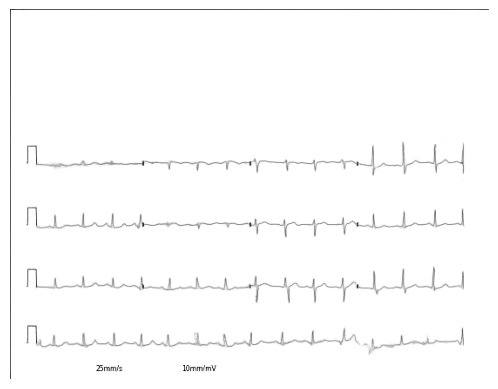

In [19]:
plt.imshow(validation_images[5], cmap='gray')
plt.axis('off')
plt.show()

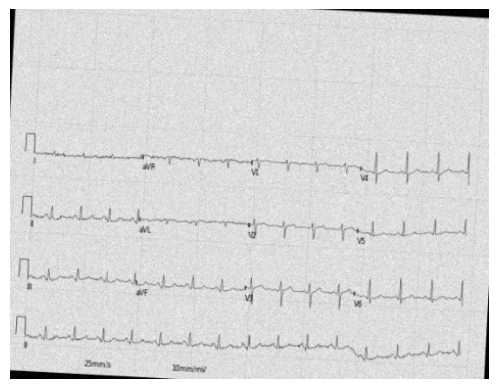

In [20]:
plt.imshow(val_noisy[5], cmap='gray')
plt.axis('off')
plt.show()

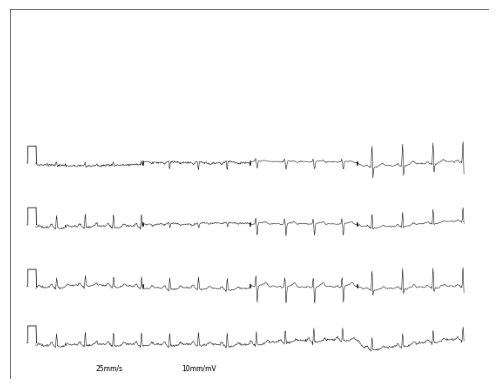

In [21]:
plt.imshow(val_clean[5], cmap='gray')
plt.axis('off')
plt.show()

In [22]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

ssim_scores = []
dice_scores = []

for img, ref in zip(validation_images, val_clean):
    # --- Normalize or ensure binary if segmentation masks ---
    img = np.clip(img, 0, 1)
    ref = np.clip(ref, 0, 1)

    # --- SSIM Calculation ---
    h, w = img.shape[:2]
    win_size = 7
    if min(h, w) < win_size:
        win_size = min(h, w)
        if win_size % 2 == 0:
            win_size -= 1
    score_ssim = ssim(img, ref, channel_axis=-1, win_size=win_size, data_range=1.0)
    ssim_scores.append(score_ssim)

    # --- Dice Coefficient Calculation ---
    # Threshold if not binary (for grayscale or normalized float images)
    img_bin = (img > 0.5).astype(np.float32)
    ref_bin = (ref > 0.5).astype(np.float32)

    intersection = np.sum(img_bin * ref_bin)
    dice = (2. * intersection) / (np.sum(img_bin) + np.sum(ref_bin) + 1e-8)
    dice_scores.append(dice)

# --- Results ---
average_ssim = np.mean(ssim_scores)
average_dice = np.mean(dice_scores)

print(f"Average SSIM: {average_ssim:.4f}")
print(f"Average Dice Score: {average_dice:.4f}")


Average SSIM: 0.9308
Average Dice Score: 0.9972
